Plotting of trajs

In [ ]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ---- 1. Set the project root folder ----
project_root = "/Users/nicodemussoh/Documents/mpc_MuJoCo"

# ---- 2. Change working directory to project root ----
os.chdir(project_root)
print("Current working directory:", os.getcwd())

# ---- 3. Add root to sys.path for imports ----
if project_root not in sys.path:
    sys.path.append(project_root)
    
from data_collection.data_utils import load_npz

# -----------------------------
# Load Data
# -----------------------------

# NN data
nn5_data = load_npz(
    "data/2026-02-26_12-23-53_TwoDofArm_NN_5_e38/2026-02-26_12-23-53_logs.npz"
)

# MPC datasets
mpc_data_5 = load_npz(
    "data/2026-02-25_15-03-55_TwoDofArm_N5/2026-02-25_15-03-55_logs.npz"
)

mpc_data_10 = load_npz(
    "data/2026-02-25_15-04-49_TwoDofArm_N10/2026-02-25_15-04-49_logs.npz"
)

mpc_data_50 = load_npz(
    "data/2026-02-25_15-24-50_TwoDofArm_N50/2026-02-25_15-24-50_logs.npz"
)

# -----------------------------
# Extract trajectories
# xyz_traj[..., 0] = x
# xyz_traj[..., 1] = y
# xyz_traj[..., 2] = z
# -----------------------------

mpc_traj_5 = mpc_data_5["default"]["xyz_traj"]
mpc_traj_10 = mpc_data_10["default"]["xyz_traj"]
mpc_traj_50 = mpc_data_50["default"]["xyz_traj"]
nn_traj_5 = nn5_data["default"]["xyz_traj"]

# Extract X and Z components
mpc_x_5 = mpc_traj_5[:, :, 0]
mpc_z_5 = mpc_traj_5[:, :, 2]

mpc_x_10 = mpc_traj_10[:, :, 0]
mpc_z_10 = mpc_traj_10[:, :, 2]

mpc_x_50 = mpc_traj_50[:, :, 0]
mpc_z_50 = mpc_traj_50[:, :, 2]

nn_x_5 = nn_traj_5[:, :, 0]
nn_z_5 = nn_traj_5[:, :, 2]

# -----------------------------
# Time + Horizon lengths
# -----------------------------

T = min(
    mpc_x_5.shape[0],
    mpc_x_10.shape[0],
    mpc_x_50.shape[0],
    nn_x_5.shape[0],
)

H_mpc_5 = mpc_x_5.shape[1] - 1
H_mpc_10 = mpc_x_10.shape[1] - 1
H_mpc_50 = mpc_x_50.shape[1] - 1
H_nn_5 = nn_x_5.shape[1] - 1

# -----------------------------
# Figure setup
# -----------------------------

fig, ax = plt.subplots(figsize=(6, 6))

ax.set_xlabel("x")
ax.set_ylabel("z")
ax.set_title("MPC vs MPC + NN (X-Z Plane)")

ax.set_xlim(-0.8, 0.4)
ax.set_ylim(1.0, 2.0)

ax.set_aspect("equal", adjustable="box")
ax.grid(True)

# -----------------------------
# Start and Goal points (X-Z)
# -----------------------------

x0 = [0.3079166867244125, 0.0, 1.4171682076907781]
yref = [-0.5522350408628973, 0.0, 1.2858399579259427]

# Extract X and Z
x0_x, x0_z = x0[0], x0[2]
goal_x, goal_z = yref[0], yref[2]

# Plot start
ax.scatter(
    x0_x, x0_z,
    color="black",
    s=120,
    marker="o",
    label="Start"
)

# Plot goal
ax.scatter(
    goal_x, goal_z,
    color="gold",
    edgecolor="black",
    s=150,
    marker="*",
    label="Goal"
)

# Lines
mpc_line_5, = ax.plot([], [], color='purple', marker='.', lw=2,
                      markersize=3, label=f"MPC 5 (H={H_mpc_5})", alpha=0.3)

mpc_line_10, = ax.plot([], [], color='blue', marker='.', lw=2,
                       markersize=3, label=f"MPC 10 (H={H_mpc_10})", alpha=0.3)

mpc_line_50, = ax.plot([], [], color='green', marker='.', lw=2,
                       markersize=3, label=f"MPC 50 (H={H_mpc_50})", alpha=0.3)

nn_line_5, = ax.plot([], [], color='red', marker='.', lw=2,
                     markersize=3, label=f"NN 5 (H={H_nn_5})", alpha=0.3)

# Current points
mpc_point_5, = ax.plot([], [], color='purple', markersize=10, marker='s')
mpc_point_10, = ax.plot([], [], color='blue', markersize=10, marker='p')
mpc_point_50, = ax.plot([], [], color='green', markersize=10, marker='^')
nn_point_5, = ax.plot([], [], color='red', markersize=10, marker='d')

ax.legend()

# -----------------------------
# Animation update
# -----------------------------

def update(t):

    # MPC 5
    mpc_line_5.set_data(mpc_x_5[t], mpc_z_5[t])
    mpc_point_5.set_data([mpc_x_5[t, 0]], [mpc_z_5[t, 0]])

    # MPC 10
    mpc_line_10.set_data(mpc_x_10[t], mpc_z_10[t])
    mpc_point_10.set_data([mpc_x_10[t, 0]], [mpc_z_10[t, 0]])

    # MPC 50
    mpc_line_50.set_data(mpc_x_50[t], mpc_z_50[t])
    mpc_point_50.set_data([mpc_x_50[t, 0]], [mpc_z_50[t, 0]])

    # NN 5
    nn_line_5.set_data(nn_x_5[t], nn_z_5[t])
    nn_point_5.set_data([nn_x_5[t, 0]], [nn_z_5[t, 0]])

    return (
        mpc_line_5, mpc_point_5,
        mpc_line_10, mpc_point_10,
        mpc_line_50, mpc_point_50,
        nn_line_5, nn_point_5
    )

# -----------------------------
# Run animation
# -----------------------------

ani = FuncAnimation(fig, update, frames=T, interval=60, blit=True)

ani.save("xz_plane_animation.mp4", writer="ffmpeg", fps=30, dpi=300)

print("Animation saved as xz_plane_animation.mp4")

In [ ]:
import os
import sys
import numpy as np

# ---- 1. Set the project root folder ----
# Adjust this to the path of your main project folder
project_root = "/Users/nicodemussoh/Documents/mpc_MuJoCo"  # e.g., "/Users/you/Documents/mpc_MuJoCo"

# ---- 2. Change working directory to project root ----
os.chdir(project_root)
print("Current working directory:", os.getcwd())

# ---- 3. Add root to sys.path for imports ----
if project_root not in sys.path:
    sys.path.append(project_root)
    
# Plot cost graph over time
import matplotlib.pyplot as plt
from data_collection.data_utils import load_npz

# Load NN data
nn2_data = load_npz("data/2026-02-25_15-29-43_TwoDofArm_NN_5_e60/2026-02-25_15-29-43_logs.npz")

# Extract total_cost arrays
nn2_cost = nn2_data["default"]["terminal_cost"]
GT_mpc_cost = nn2_data["default"]["GT_cost"]

# Create a time vector for each (assume uniform 1 step per time step)
t_GT_mpc = np.arange(len(GT_mpc_cost))
t_nn2 = np.arange(len(nn2_cost))

# Plot
plt.figure(figsize=(10, 6))

plt.plot(t_GT_mpc, GT_mpc_cost, label="MPC H=250", color="orange")
plt.plot(t_nn2, nn2_cost, label="NN H=2", linestyle="--", color="purple")

plt.xlabel("Time step")
plt.ylabel("Total Cost")
plt.yscale("log")
plt.title("GT MPC Vs Neural Network at Terminal State")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Plot absolute error between NN H=2 and MPC H=100
import numpy as np
import matplotlib.pyplot as plt
from data_collection.data_utils import load_npz

# Load NN data
nn2_data = load_npz("data/2026-02-25_15-29-43_TwoDofArm_NN_5_e60/2026-02-25_15-29-43_logs.npz")
GT_mpc_cost = nn2_data["default"]["GT_cost"]
nn2_cost = nn2_data["default"]["total_cost"]

# Make sure the arrays are the same length (truncate to the shorter one)
T = min(len(nn2_cost), len(GT_mpc_cost))
abs_error = np.abs(nn2_cost[:T] - GT_mpc_cost[:T])

# Time vector
t = np.arange(T)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(t, abs_error, color="red", label="|NN H=2 - MPC H=100|")

plt.xlabel("Time step")
plt.ylabel("Absolute Error")
plt.yscale("log")
plt.title("Absolute Error between NN H=2 and MPC H=100")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
  yref:
  - -0.5522350408628973
  - 0.0
  - 1.2858399579259427

  yref_q:
  - 0.24
  - -1.21
  - 0.0
  - 0.0

In [16]:
# Evaluate the NN at the set point.
import torch
import numpy as np
from neural_network.models import TwoDofArmModel

# -----------------------------
# Load model
# -----------------------------
weights_path = "value_iteration/output/2026-02-22_15-19-00_TwoDofArm_VI/loop_60/training/model_epoch_16.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TwoDofArmModel(None)
model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()

# -----------------------------
# Define inputs
# -----------------------------

# Cartesian target
yref = np.array([
    -0.5522350408628973,
    0.0,
    1.2858399579259427
], dtype=np.float32)

# Joint reference
yref_q = np.array([
    0.24,
    -1.21,
    0.0,
    0.0
], dtype=np.float32)

# Concatenate
input_vec = np.concatenate([yref_q, yref])   # shape (7,)

# Convert to torch tensor with batch dimension
input_tensor = torch.tensor(input_vec, dtype=torch.float32).unsqueeze(0).to(device)

# -----------------------------
# Evaluate model
# -----------------------------

with torch.no_grad():
    output = model(input_tensor)

print("Input:", input_vec)
print("Model output:", output.cpu().numpy())

Input: [ 0.24       -1.21        0.          0.         -0.55223507  0.
  1.2858399 ]
Model output: [[0.4491743]]


Model loaded on: cpu


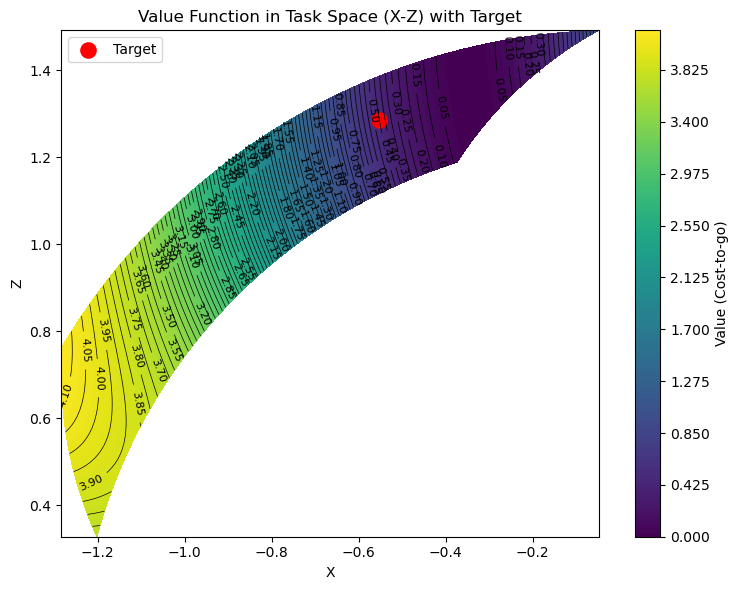

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

# ---- 1. Set project root ----
project_root = "/Users/nicodemussoh/Documents/mpc_MuJoCo"
os.chdir(project_root)
if project_root not in sys.path:
    sys.path.append(project_root)

from neural_network.models import TwoDofArmModel

# ============================================================
# 1. Load Model
# ============================================================
weights_path = "value_iteration/output/2026-02-22_15-19-00_TwoDofArm_VI/loop_60/training/model_epoch_16.pt"
# weights_path = "value_iteration/output/2026-02-25_21-18-22_TwoDofArm_VI/loop_38/training/model_epoch_15.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TwoDofArmModel(None)
model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()
print("Model loaded on:", device)

# ============================================================
# 2. Target (from YAML)
# ============================================================
yref = np.array([
    -0.5522350408628973,  # original x
    0.0,                   # original y
    1.2858399579259427     # original z
], dtype=np.float32)

# ============================================================
# 3. Arm Parameters
# ============================================================
l1 = 0.8
l2 = 0.9

def forward_kinematics(q1, q2):
    """Vectorized FK over arrays."""
    z = l1 * np.cos(q1) + l2 * np.cos(q1 + q2)
    x = l1 * np.sin(q1) + l2 * np.sin(q1 + q2)
    return x, z

# ============================================================
# 4. Create Grid in Joint Space
# ============================================================
grid_size = 100
q1_vals = np.linspace(-0.5, 0.5, grid_size)
q2_vals = np.linspace(-1.5, -1.0, grid_size)
Q1, Q2 = np.meshgrid(q1_vals, q2_vals)  # shape (grid_size, grid_size)

# ============================================================
# 5. Compute FK for the grid
# ============================================================
x_grid, z_grid = forward_kinematics(Q1, Q2)  # shape (grid_size, grid_size)

# ============================================================
# 6. Remap target to FK axes
# ============================================================
x_target = yref[0]  # z in YAML → x in FK
z_target = yref[2]  # x in YAML → z in FK

# ============================================================
# 7. Build NN input batch
# Each input: [q1, q2, qdot1, qdot2, x_ref, y_ref, z_ref]
# ============================================================
inputs = np.zeros((grid_size, grid_size, 7), dtype=np.float32)
inputs[:, :, 0] = Q1           # q1
inputs[:, :, 1] = Q2           # q2
inputs[:, :, 2] = 0.0          # qdot1
inputs[:, :, 3] = 0.0          # qdot2
inputs[:, :, 4] = x_target     # fixed target x_ref
inputs[:, :, 5] = 0.0          # y_ref (can remain 0)
inputs[:, :, 6] = z_target     # fixed target z_ref

# Flatten for batch evaluation
inputs_flat = inputs.reshape(-1, 7)
inputs_tensor = torch.from_numpy(inputs_flat).to(device)

# ============================================================
# 8. Evaluate NN
# ============================================================
with torch.no_grad():
    values_flat = model(inputs_tensor).cpu().numpy().flatten()

# Reshape back to grid
cost_grid = values_flat.reshape(grid_size, grid_size)

# ============================================================
# 9. Plot Value in Task Space (X-Z) with Target
# ============================================================
# plt.figure(figsize=(8,6))
# contour = plt.contourf(x_grid, z_grid, cost_grid, levels=200, cmap='viridis')
# plt.colorbar(contour, label="Value (Cost-to-go)")

# # Plot target (aligned with FK axes)
# plt.scatter(x_target, z_target, color='red', s=120, label="Target")
# plt.xlabel("X")
# plt.ylabel("Z")
# plt.title("Value Function in Task Space (X-Z) with Target")
# plt.gca().set_aspect('equal', adjustable='box')
# plt.legend()
# plt.tight_layout()
# plt.show()

plt.figure(figsize=(8,6))

# Filled contours
contourf = plt.contourf(x_grid, z_grid, cost_grid,
                        levels=200,
                        cmap='viridis')

# Contour lines (add this)
contour_lines = plt.contour(x_grid, z_grid, cost_grid,
                            levels=100,      # fewer levels for readable lines
                            colors='black',
                            linewidths=0.5)

plt.colorbar(contourf, label="Value (Cost-to-go)")

# Optional: label contour lines
plt.clabel(contour_lines, inline=True, fontsize=8)

# Plot target
plt.scatter(x_target, z_target,
            color='red', s=120, label="Target")

plt.xlabel("X")
plt.ylabel("Z")
plt.title("Value Function in Task Space (X-Z) with Target")
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.tight_layout()
plt.show()

In [2]:
import os
import sys

# ---- 1. Set the project root folder ----
# Adjust this to the path of your main project folder
project_root = "/Users/nicodemussoh/Documents/mpc_MuJoCo"  # e.g., "/Users/you/Documents/mpc_MuJoCo"

# ---- 2. Change working directory to project root ----
os.chdir(project_root)
print("Current working directory:", os.getcwd())

# ---- 3. Add root to sys.path for imports ----
if project_root not in sys.path:
    sys.path.append(project_root)
    
# Evaluate the NN at the set point.
import torch
import numpy as np
from neural_network.models import TwoDofArmModel

# -----------------------------
# Load model
# -----------------------------
weights_path = "value_iteration/output/2026-02-25_21-18-22_TwoDofArm_VI/loop_38/training/model_epoch_15.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TwoDofArmModel(None)
model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()

# -----------------------------
# Define inputs
# -----------------------------

# Cartesian target
yref = np.array([
    -0.5522350408628973,
    0.0,
    1.2858399579259427
], dtype=np.float32)

# Joint reference
yref_q = np.array([
    0.24,
    -1.21,
    0.0,
    0.0
], dtype=np.float32)

# Concatenate
input_vec = np.concatenate([yref_q, yref])   # shape (7,)

# Convert to torch tensor with batch dimension
input_tensor = torch.tensor(input_vec, dtype=torch.float32).unsqueeze(0).to(device)

# -----------------------------
# Evaluate model
# -----------------------------

with torch.no_grad():
    output = model(input_tensor)

print("Input:", input_vec)
print("Model output:", output.cpu().numpy())

Current working directory: /Users/nicodemussoh/Documents/mpc_MuJoCo


Input: [ 0.24       -1.21        0.          0.         -0.55223507  0.
  1.2858399 ]
Model output: [[0.06035744]]
